In [2]:
import numpy as np
import pandas as pd

from pathlib import Path
import matplotlib.pyplot as plt
from darts import TimeSeries

In [3]:
# load nab data into a dictionary
def load_nab():
    nab_data_folder = Path('data/nab_data_corpus')
    nab_data = {}
    for dir in nab_data_folder.glob('*'):
        if (dir / dir.name).exists():
            nab_data[dir.name] = {}
            sub_dir = dir / dir.name
            for file in sub_dir.rglob('*.csv'):
                if file.is_file():
                    nab_data[dir.name][file.name[:-4]] = {}
                    nab_data[dir.name][file.name[:-4]]['path'] = file
                    df = pd.read_csv(file)
                    df['timestamp'] = pd.to_datetime(df['timestamp'])
                    nab_data[dir.name][file.name[:-4]]['df'] = df
    return nab_data

def plot_folder_files(folder, nab_data):
    folder_data = nab_data[folder]
    fig, axes = plt.subplots(len(folder_data.keys()), 1, figsize=(18, 12))
    axes.flatten()
    for index, file in enumerate(nab_data[folder].keys()):
        nab_data[folder][file]['df'].plot(x='timestamp', y='value', ax=axes[index], title=file, legend=False)
    plt.tight_layout(pad=2.0)


In [ ]:
nab = load_nab()

plot_folder_files('artificialWithAnomaly', load_nab())

<Axes: title={'center': 'original'}, xlabel='timestamp'>

Error in callback <function _draw_all_if_interactive at 0x7f3ad24b63e0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

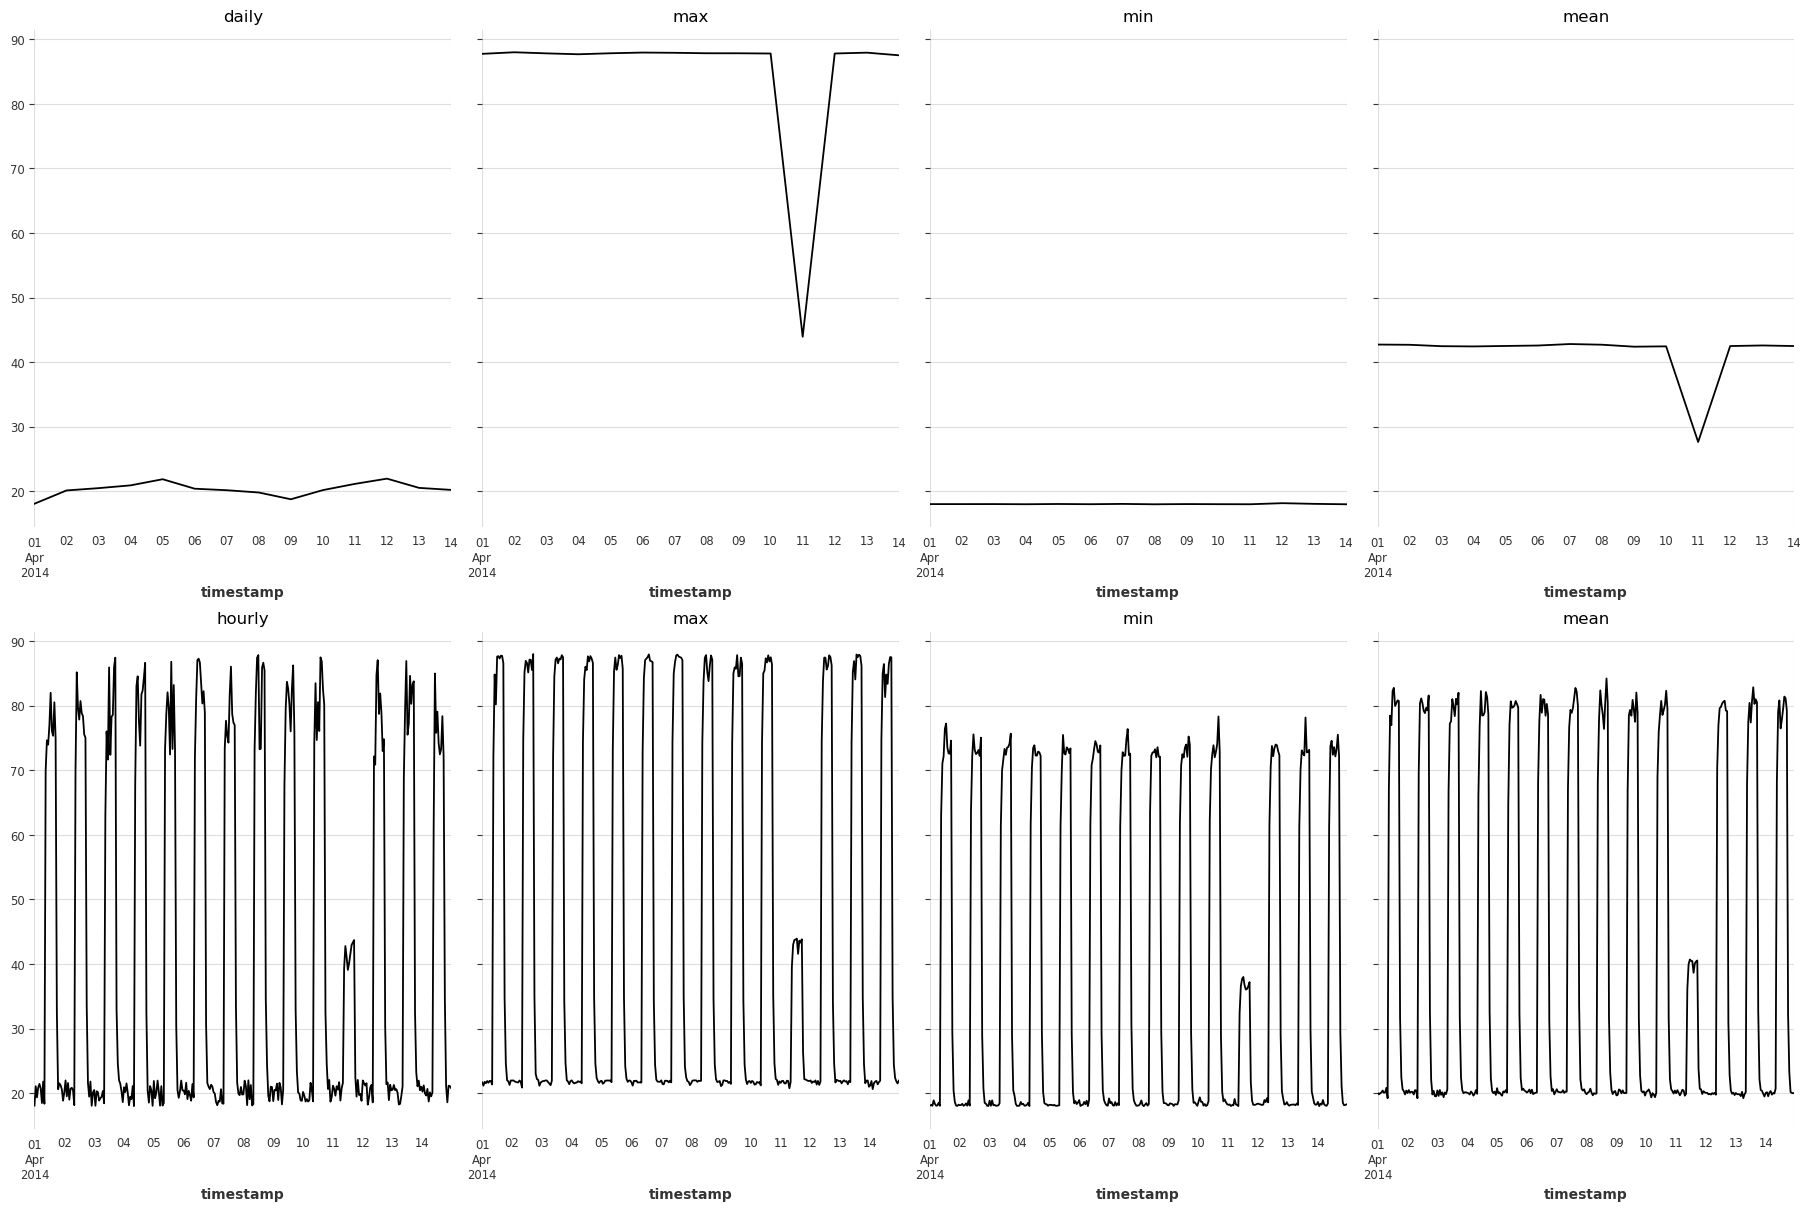

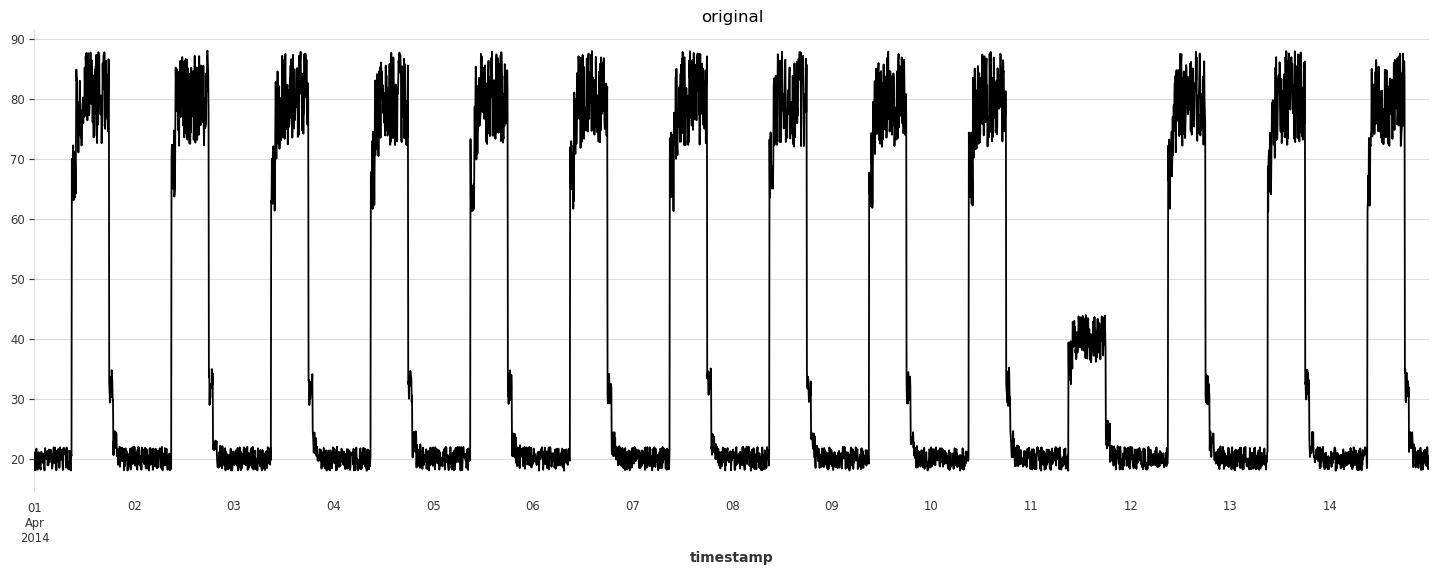

In [124]:
original = nab['artificialWithAnomaly']['art_daily_jumpsdown']['df']
original['timestamp'] = pd.to_datetime(original['timestamp'])
original = original.set_index('timestamp')


data_views_daily = {'daily':original.asfreq('D'), 'max':original.resample('D').max(), 'min':original.resample('D').min(), 'mean':original.resample('D').mean()}
data_views_hourly = {'hourly':original.asfreq('h'), 'max':original.resample('h').max(), 'min':original.resample('h').min(), 'mean':original.resample('h').mean()}

fig, axes = plt.subplots(2, 4, figsize=(18, 12), sharey='row', constrained_layout=True)
axes = axes.flatten()

for idx, key in enumerate(data_views_daily.keys()):
    data_views_daily[key].plot(y='value', legend=False, title=f'{key}', ax=axes[:4][idx])

for idx, key in enumerate(data_views_hourly.keys()):
    data_views_hourly[key].plot(y='value', legend=False, title=f'{key}', ax=axes[4:][idx])

original.plot(y='value', legend=False, title='original', figsize=(18,6))



In [86]:
def get_coeff_var(dict):
    for key in dict.keys():
        coeff_var = dict[key].std()/dict[key].mean()
        print(f'Coefficient of Variance for {key}: {coeff_var.value}')
    return map(lambda x: (x.std()/x.mean()).value, dict.values())

cov_original = (original.std()/original.mean()).value

print(f'Coefficient of Vartion for original: {(original.std()/original.mean()).value}')

covs_hourly = get_coeff_var(data_views_hourly)
print(f'{[abs(1-(cov/cov_original))*100 for cov in covs_hourly]}')
print('\n')

covs_daily = get_coeff_var(data_views_daily)
print(f'{[abs(1-(cov/cov_original))*100 for cov in covs_daily]}')
print('\n')

def get_std(dict):
    for key, val in dict.items():
        print(f'Standard deviation of {key}: {val.std().value}')
    print('\n')

print(f'original standard deviation: {original.std().value}')
get_std(data_views_hourly)
get_std(data_views_daily)

Coefficient of Vartion for original: 0.6627845022329666
Coefficient of Variance for hourly: 0.6648611316175388
Coefficient of Variance for max: 0.6609446891953316
Coefficient of Variance for min: 0.6617948560854472
Coefficient of Variance for mean: 0.6603859131193591
[np.float64(0.31331894116048975), np.float64(0.27758842149093743), np.float64(0.14931642852016314), np.float64(0.36189577540308715)]


Coefficient of Variance for daily: 0.05102342650566787
Coefficient of Variance for max: 0.1384923613637889
Coefficient of Variance for min: 0.002447476040998811
Coefficient of Variance for mean: 0.09615473737189462
[np.float64(92.30165667215114), np.float64(79.10446594674458), np.float64(99.63072823327144), np.float64(85.49230752258951)]


original standard deviation: 27.512033426229266
Standard deviation of hourly: 27.70474851049266
Standard deviation of max: 29.73025555967364
Standard deviation of min: 25.133148708790632
Standard deviation of mean: 27.412468539532263


Standard deviation 

Text(0.5, 1.0, 'Dailiy')

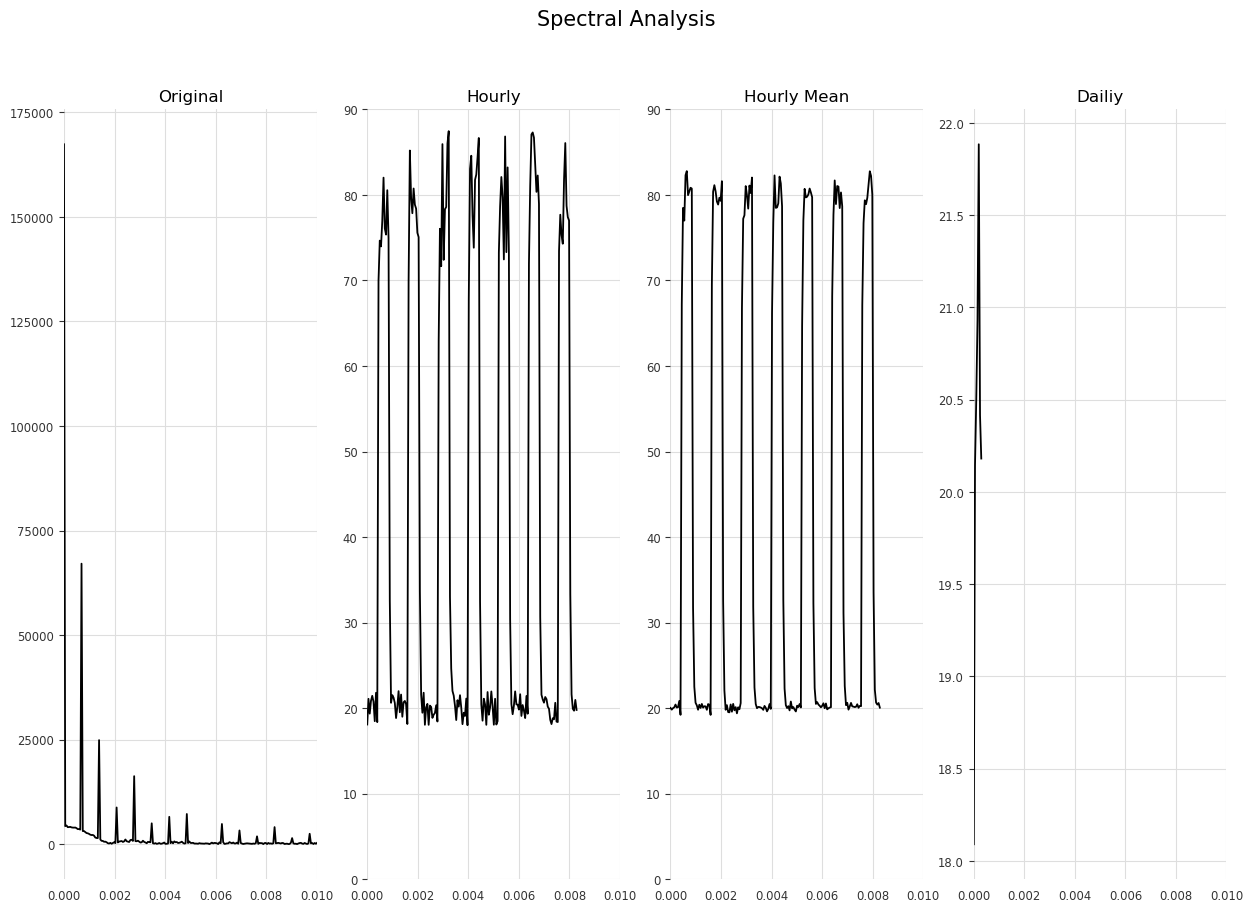

In [123]:
from numpy.fft import fftfreq, fft
original_spectrum = fft(original['value'])
n_original = original['value'].size
d_original = 5

hourly_spectrum = fft(data_views_hourly['hourly'])
hourly_mean_spectrum = fft(data_views_hourly['mean'])
d_hourly = 60
n_hourly = data_views_hourly['hourly'].size

daily_spectrum = fft(data_views_daily['daily'])
n_daily = data_views_daily['daily'].size
d_daily = 60*24

original_freqs = fftfreq(n_original, d_original)
hourly_freqs = fftfreq(n_hourly, d_hourly)
daily_freqs = fftfreq(n_daily, d_daily)



fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15,10), sharex=True)
fig.suptitle('Spectral Analysis', size=15)
ax1.plot(original_freqs[:n_original//2], np.abs(original_spectrum)[:n_original//2])
ax1.set_title('Original')
ax1.set_xlim((0, 1/100))
ax2.plot(hourly_freqs[:n_hourly//2], np.abs(hourly_spectrum)[:n_hourly//2])
ax2.set_title('Hourly')
ax2.set_ylim((0,90))
ax3.plot(hourly_freqs[:n_hourly//2], np.abs(hourly_mean_spectrum)[:n_hourly//2])
ax3.set_title('Hourly Mean')
ax3.set_ylim((0, 90))
ax4.plot(daily_freqs[:n_daily//2], np.abs(daily_spectrum)[:n_daily//2])
ax4.set_title('Dailiy')
